### Import Libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_curve, confusion_matrix


### Load the dataset

In [3]:
data=pd.read_csv("Crop_recommendation.csv")
display(data.head())
print(data.shape)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


(2200, 8)


<Axes: >

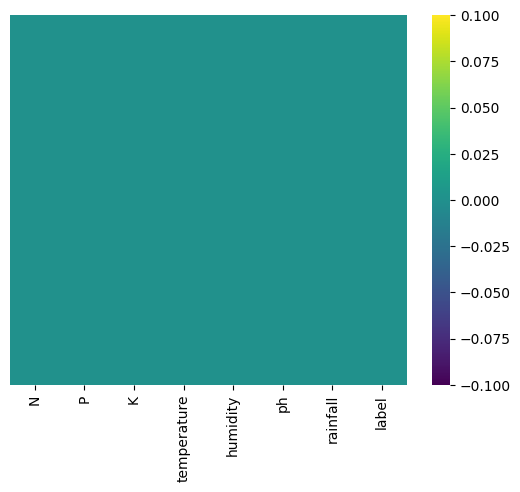

In [8]:
data.isnull().sum()
sns.heatmap(data.isnull(),cbar=True,yticklabels=False,cmap='viridis')

### Train Test split

In [ ]:
x=data.iloc[:,:-1]  #features
y=data.iloc[:,-1]   #Target variable

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1760, 7), (440, 7), (1760,), (440,))

### Training the model

In [ ]:
rf=RandomForestClassifier(n_estimators=50)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy_score(y_test,y_pred)

0.9886363636363636

In [13]:
df=pd.DataFrame({'Labels':y_test,'Prediction':y_pred})
df

,Labels,Prediction
1451,muskmelon,muskmelon
1334,watermelon,watermelon
1761,papaya,papaya
1735,papaya,papaya
1576,apple,apple
...,...,...
59,rice,rice
71,rice,rice
1908,cotton,cotton
1958,cotton,cotton


In [14]:
data

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [15]:
new_features=[[100,20,25,24.355,65.435,5.554,100]]
pred=rf.predict(new_features)
print("Predicted crop:",pred)

Predicted crop: ['coffee']


e:\Github Projects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
# Make pickle of the model
import pickle
pickle.dump(rf,open("model.pkl","wb"))

